# Layout Generation -- placing speculative new farms

I developed this engine for the Monte Carlo, after the climate emulator (`Wind_Resource`) and the density/turbine engine (`Density_Power_Study`). Given a target capacity for one new speculative farm, this generates where it goes and what it looks like: real lease shapes as templates (scaled to the right size, not invented rectangles), filtered by water depth (fixed-bottom only) and by plausible distance to a real point of interconnection, placed on a distance x alignment-sector grid relative to the center of our are interested (center of MA CLUSTER).

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import yaml
import windIO
from shapely.geometry import Polygon, Point
from shapely import affinity
from scipy.spatial import cKDTree

from staircase import grow_staircase_boundary

DATA_DIR = Path("..") / ".." / "Data"
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

COLORS = {"Haliade-X 13MW": "#1B6E86", "Haliade-X 15.5MW": "#2E8CA6", "DTU10MW": "#C17A1F"}

def load_turbine(fname):
    with open(DATA_DIR / fname) as f:
        d = yaml.safe_load(f)
    return dict(diameter=d["rotor_diameter"], rated_mw=d["performance"]["rated_power"] / 1e6)

TURBINES = {
    "Haliade-X 13MW": load_turbine("haliadex_13mw.yaml"),
    "Haliade-X 15.5MW": load_turbine("haliadex_15.5.yaml"),
    "DTU10MW": load_turbine("dtu10mw.yaml"),
}

## 1. Real leases -- reference geometry, not pieces

`LEASE_TEMPLATES` is still every real lease polygon in this cluster, used two ways below: (a) `existing_shapes` starts from these 13, so new speculative farms never land on top of a real one, and (b) they were the calibration set for `staircase.py`'s boundary generator (Section 5 --- SEE LATER) 

In [2]:
BOUNDARY_NAMES = [
    "Vineyard Wind", "Revolution Wind", "SouthCoast Wind", "South Fork Wind",
    "Sunrise Wind South", "Sunrise Wind North", "Revolution Wind North",
    "Vineyard Northeast", "New England Wind 1", "New England Wind 2 South",
    "Beacon Wind", "Bay State Wind South", "Bay State Wind North",
]

site_us = windIO.load_yaml(DATA_DIR / "site_us.yaml")
boundary_polygons = site_us["boundaries"]["polygons"]
wind_farm_us = windIO.load_yaml(DATA_DIR / "wind_farm_us.yaml")

LEASE_TEMPLATES = {
    name: Polygon(zip(p["x"], p["y"]))
    for name, p in zip(BOUNDARY_NAMES, boundary_polygons)
}

for name, poly in LEASE_TEMPLATES.items():
    print(f"{name}: {poly.area / 1e6:.1f} km2")

Vineyard Wind: 264.2 km2
Revolution Wind: 334.5 km2
SouthCoast Wind: 515.6 km2
South Fork Wind: 55.5 km2
Sunrise Wind South: 430.9 km2
Sunrise Wind North: 14.4 km2
Revolution Wind North: 4.3 km2
Vineyard Northeast: 535.7 km2
New England Wind 1: 212.5 km2
New England Wind 2 South: 197.9 km2
Beacon Wind: 521.2 km2
Bay State Wind South: 579.2 km2
Bay State Wind North: 7.2 km2


### 1.1 Template gallery

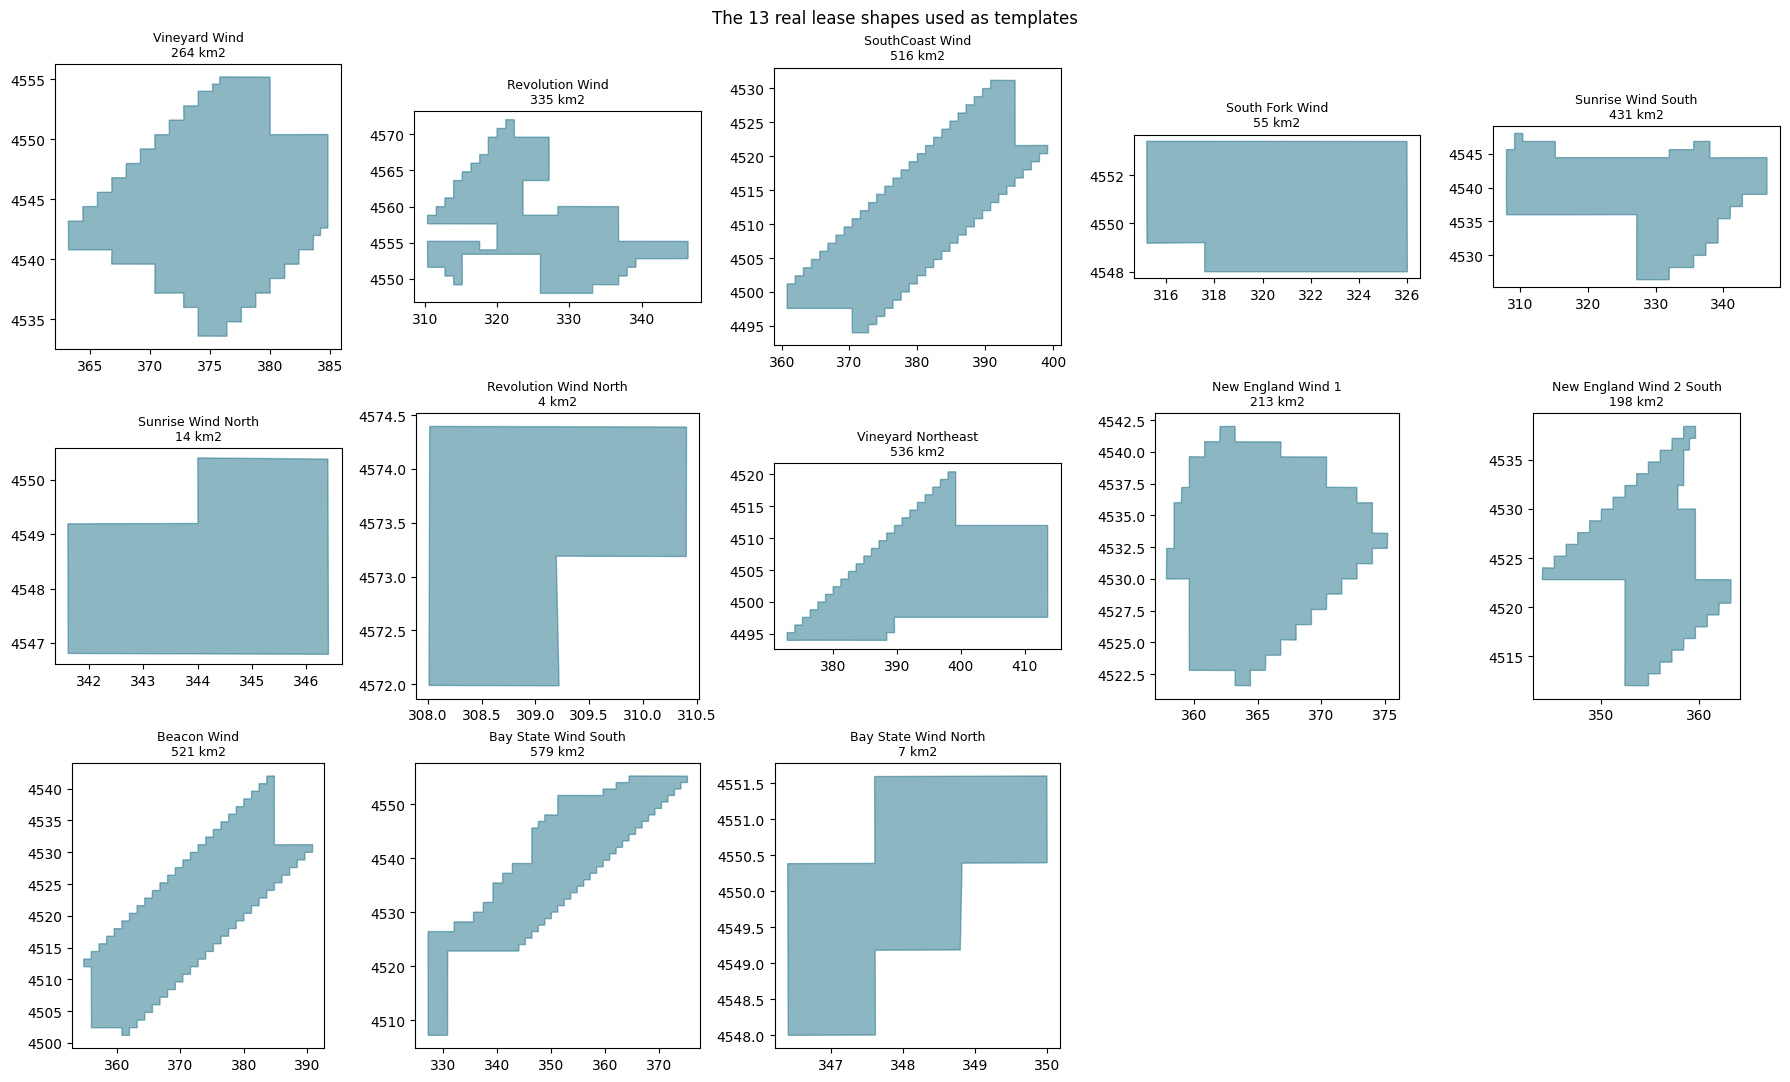

In [3]:
fig, axes = plt.subplots(3, 5, figsize=(18, 11))
for ax, (name, poly) in zip(axes.flat, LEASE_TEMPLATES.items()):
    x, y = poly.exterior.xy
    ax.fill(np.array(x) / 1000, np.array(y) / 1000, color="#1B6E86", alpha=0.5)
    ax.set_title(f"{name}\n{poly.area / 1e6:.0f} km2", fontsize=9)
    ax.set_aspect("equal")
for ax in axes.flat[len(LEASE_TEMPLATES):]:
    ax.axis("off")
fig.suptitle("The 13 real lease shapes used as templates")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lease_template_gallery.png", dpi=180, bbox_inches="tight")
plt.show()

## 1.2 Filling the rest of the cluster -- Generator A

Two different generators, not one. Generator A (here): the 9 leases that already have a real, fixed boundary but no published turbine layout (SouthCoast, Sunrise Wind North, Revolution Wind North, Vineyard Northeast, New England Wind 1, New England Wind 2 South, Beacon Wind, Bay State Wind South/North) -- position never varies, only the fill (turbine choice, spacing) does, same mechanism as `Density_Power_Study` Case 1. Combined with the 4 leases that do have a real published layout (Vineyard, Revolution, South Fork, Sunrise Wind South), this gives one fully populated "cluster FULL" -- the fixed starting point every scenario builds on. Generator B , i called (Section 5) only ever adds new farms around this, never touches its position.

In [4]:
def grid_fill_points(polygon, diameter, spacing_d):
    spacing = spacing_d * diameter
    xmin, ymin, xmax, ymax = polygon.bounds
    xs = np.arange(xmin, xmax + spacing, spacing)
    ys = np.arange(ymin, ymax + spacing, spacing)
    return np.array([(x, y) for x in xs for y in ys if polygon.contains(Point(x, y))])

REAL_LAYOUT_FARMS = {"Vineyard Wind", "Revolution Wind", "South Fork Wind", "Sunrise Wind South"}

REAL_FARM_X, REAL_FARM_Y = [], []
for farm in wind_farm_us:
    REAL_FARM_X.append(np.array(farm["layouts"][0]["coordinates"]["x"]))
    REAL_FARM_Y.append(np.array(farm["layouts"][0]["coordinates"]["y"]))

def fill_rest_of_cluster(rng, verbose=False):
    """The 4 real-layout farms never move; the other 9 leases keep their real boundary
    but get a fresh random turbine + spacing fill every time this is called -- so Bay
    State, Beacon, SouthCoast etc. vary draw to draw, same as the new speculative farms."""
    fill_x, fill_y = list(REAL_FARM_X), list(REAL_FARM_Y)
    for name in BOUNDARY_NAMES:
        if name in REAL_LAYOUT_FARMS:
            continue
        turbine_name = rng.choice(list(TURBINES.keys()))
        spacing_d = rng.uniform(8.0, 11.0)
        pts = grid_fill_points(LEASE_TEMPLATES[name], TURBINES[turbine_name]["diameter"], spacing_d)
        if len(pts):
            fill_x.append(pts[:, 0])
            fill_y.append(pts[:, 1])
        if verbose:
            print(f"{name}: filled with {turbine_name} @ {spacing_d:.1f}D -> {len(pts)} turbines")
    return np.concatenate(fill_x), np.concatenate(fill_y)

cluster_all_x, cluster_all_y = fill_rest_of_cluster(np.random.default_rng(42), verbose=True)
print(f"\nFull cluster (\'cluster cheio\'), one example fill: {len(cluster_all_x)} turbines across all 13 leases")

SouthCoast Wind: filled with Haliade-X 13MW @ 9.3D -> 125 turbines
Sunrise Wind North: filled with DTU10MW @ 10.6D -> 2 turbines
Revolution Wind North: filled with Haliade-X 13MW @ 8.3D -> 1 turbines
Vineyard Northeast: filled with DTU10MW @ 10.9D -> 142 turbines
New England Wind 1: filled with DTU10MW @ 10.4D -> 64 turbines
New England Wind 2 South: filled with DTU10MW @ 8.4D -> 87 turbines
Beacon Wind: filled with DTU10MW @ 9.1D -> 201 turbines
Bay State Wind South: filled with Haliade-X 15.5MW @ 10.8D -> 79 turbines
Bay State Wind North: filled with DTU10MW @ 10.5D -> 1 turbines

Full cluster ('cluster cheio'), one example fill: 937 turbines across all 13 leases


## 2. Bathymetry and federal boundary

Two geographic exclusion filters, plotted together since both cut the same map: water depth (fixed-bottom only below 60 m, Fuchs et al. 2024) and the federal/state (SLA) line, beyond which no federal lease can exist. `bathymetry_us.nc` is a scattered point cloud (518,400 points), so depth is looked up by nearest-neighbor search, not grid interpolation. The coastline shown is not a separate dataset -- it is the shallow edge of the same bathymetry cloud (the 5 m contour), used only as a visual reference.

In [5]:
import xarray as xr
import json
from pyproj import Transformer

bathy = xr.open_dataset(DATA_DIR / "bathymetry_us.nc")
bathy_xy = np.column_stack([bathy["x"].values, bathy["y"].values])
bathy_depth = bathy["depth"].values
bathy_tree = cKDTree(bathy_xy)
BATHY_X_MIN, BATHY_X_MAX = bathy_xy[:, 0].min(), bathy_xy[:, 0].max()
BATHY_Y_MIN, BATHY_Y_MAX = bathy_xy[:, 1].min(), bathy_xy[:, 1].max()
FIXED_BOTTOM_MAX_DEPTH = 80.0

def depth_at(xs, ys):
    _, idx = bathy_tree.query(np.column_stack([xs, ys]))
    return bathy_depth[idx]

def is_shallow_enough(xs, ys):
    return depth_at(xs, ys) < FIXED_BOTTOM_MAX_DEPTH

SLA_PATH = DATA_DIR.parent / "WindFarms" / "US_Cluster" / "Data" / "Federal_State_Boundary_SLA.geojson"
sla_raw = json.load(open(SLA_PATH))["features"][0]["geometry"]["coordinates"]
LON_MIN, LON_MAX, LAT_MIN, LAT_MAX = -73.0, -68.5, 40.0, 43.0
to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32619", always_xy=True)

sla_lines_utm = []
for line in sla_raw:
    pts = np.array(line)
    mask = (pts[:, 0] >= LON_MIN) & (pts[:, 0] <= LON_MAX) & (pts[:, 1] >= LAT_MIN) & (pts[:, 1] <= LAT_MAX)
    if mask.sum() < 2:
        continue
    sub = pts[mask]
    x, y = to_utm.transform(sub[:, 0], sub[:, 1])
    sla_lines_utm.append(np.column_stack([x, y]))

sla_all = np.vstack(sla_lines_utm)
tangents = np.zeros_like(sla_all)
offset = 0
for line in sla_lines_utm:
    n = len(line)
    tangents[offset:offset + n] = np.gradient(line, axis=0)
    offset += n
sla_tree = cKDTree(sla_all)

def sla_side(xs, ys):
    pts = np.column_stack([xs, ys])
    _, idx = sla_tree.query(pts)
    vec = pts - sla_all[idx]
    cross = tangents[idx, 0] * vec[:, 1] - tangents[idx, 1] * vec[:, 0]
    return np.sign(cross)

FEDERAL_SIGN = np.sign(sla_side(cluster_all_x, cluster_all_y).mean())

def is_federal(xs, ys):
    return sla_side(xs, ys) == FEDERAL_SIGN

### 2.0 Context -- full bathymetry extent before any limit is applied

Continuous depth (no threshold, no binning) over the entire area `bathymetry_us.nc` actually covers, with the SLA line for reference. This is the baseline picture -- the 80m fixed-bottom cut and the distance/angle grid discussed from here on are all limits drawn on top of this.

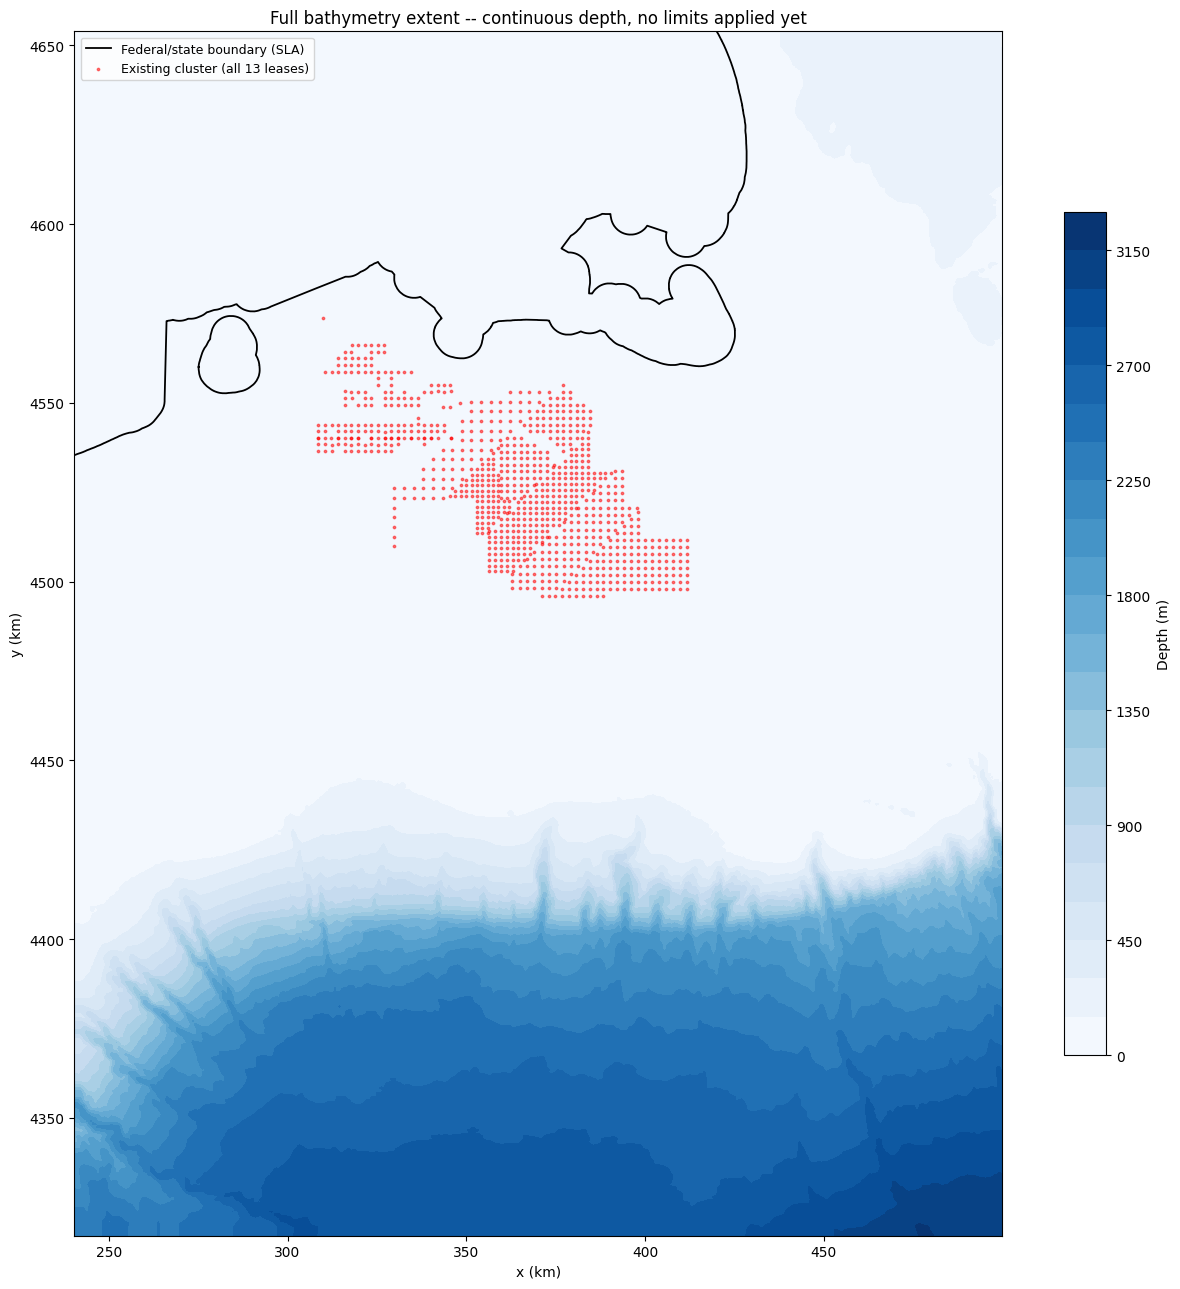

In [6]:
gx_full = np.linspace(BATHY_X_MIN, BATHY_X_MAX, 400)
gy_full = np.linspace(BATHY_Y_MIN, BATHY_Y_MAX, 400)
GXf, GYf = np.meshgrid(gx_full, gy_full)
GZf = depth_at(GXf.ravel(), GYf.ravel()).reshape(GXf.shape)

fig, ax = plt.subplots(figsize=(13, 13))
cs = ax.contourf(GXf / 1000, GYf / 1000, GZf, levels=30, cmap="Blues")
for line in sla_lines_utm:
    ax.plot(line[:, 0] / 1000, line[:, 1] / 1000, color="black", linewidth=1.3)
ax.plot([], [], color="black", linewidth=1.3, label="Federal/state boundary (SLA)")
fig.colorbar(cs, ax=ax, label="Depth (m)", shrink=0.7)
ax.scatter(cluster_all_x / 1000, cluster_all_y / 1000, s=3, color="red", alpha=0.5, label="Existing cluster (all 13 leases)")
ax.set_xlim(gx_full.min() / 1000, gx_full.max() / 1000)
ax.set_ylim(gy_full.min() / 1000, gy_full.max() / 1000)
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_aspect("equal")
ax.set_title("Full bathymetry extent -- continuous depth, no limits applied yet")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "bathymetry_full_extent_context.png", dpi=170, bbox_inches="tight")
plt.show()

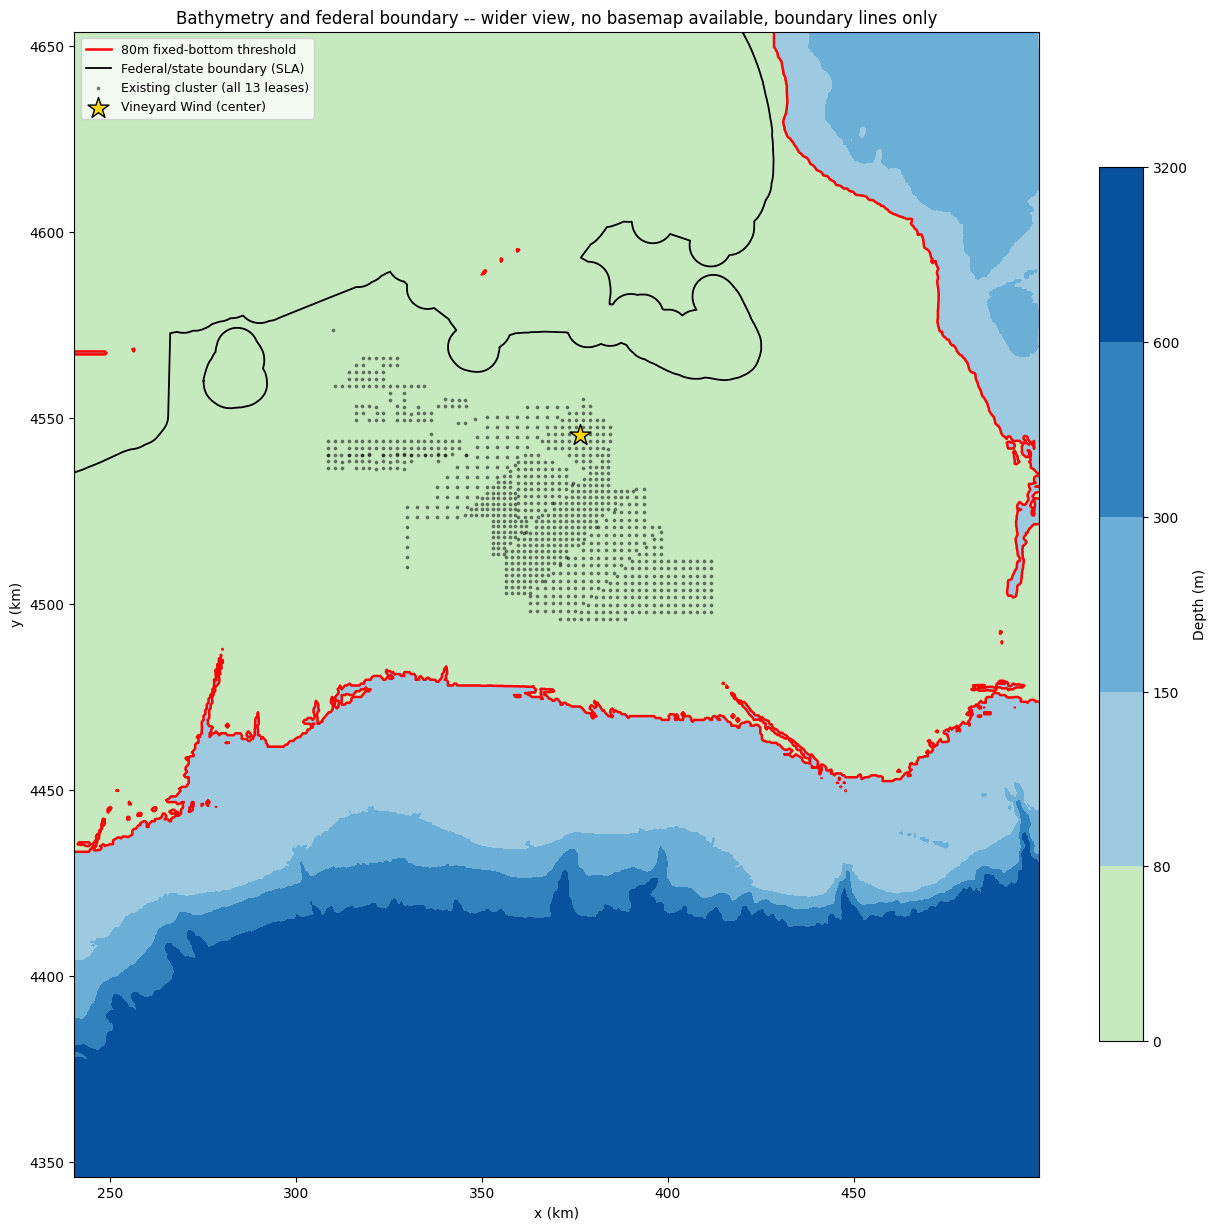

In [7]:
margin = 150_000
BATHY_X_MIN, BATHY_X_MAX = bathy_xy[:, 0].min(), bathy_xy[:, 0].max()
BATHY_Y_MIN, BATHY_Y_MAX = bathy_xy[:, 1].min(), bathy_xy[:, 1].max()
gx = np.linspace(max(cluster_all_x.min() - margin, BATHY_X_MIN), min(cluster_all_x.max() + margin, BATHY_X_MAX), 600)
gy = np.linspace(max(cluster_all_y.min() - margin, BATHY_Y_MIN), min(cluster_all_y.max() + margin, BATHY_Y_MAX), 600)
GX, GY = np.meshgrid(gx, gy)
GZ = depth_at(GX.ravel(), GY.ravel()).reshape(GX.shape)

fig, ax = plt.subplots(figsize=(13, 13))
cs = ax.contourf(GX / 1000, GY / 1000, GZ, levels=[0, FIXED_BOTTOM_MAX_DEPTH, 150, 300, 600, 3200],
                  colors=["#c7e9c0", "#9ecae1", "#6baed6", "#3182bd", "#08519c"])
ax.contour(GX / 1000, GY / 1000, GZ, levels=[FIXED_BOTTOM_MAX_DEPTH], colors="red", linewidths=1.8)
ax.plot([], [], color="red", linewidth=1.8, label=f"{FIXED_BOTTOM_MAX_DEPTH:.0f}m fixed-bottom threshold")
for line in sla_lines_utm:
    ax.plot(line[:, 0] / 1000, line[:, 1] / 1000, color="black", linewidth=1.3)
ax.plot([], [], color="black", linewidth=1.3, label="Federal/state boundary (SLA)")
fig.colorbar(cs, ax=ax, label="Depth (m)", shrink=0.7)
ax.scatter(cluster_all_x / 1000, cluster_all_y / 1000, s=3, color="black", alpha=0.4, label="Existing cluster (all 13 leases)")
vineyard_center_now = np.array([np.mean(next(f for f in wind_farm_us if f["name"] == "Vineyard Wind")["layouts"][0]["coordinates"]["x"]), np.mean(next(f for f in wind_farm_us if f["name"] == "Vineyard Wind")["layouts"][0]["coordinates"]["y"])])
ax.scatter(*vineyard_center_now / 1000, marker="*", s=250, color="gold", edgecolor="black", label="Vineyard Wind (center)", zorder=5)
ax.set_xlim(gx.min() / 1000, gx.max() / 1000)
ax.set_ylim(gy.min() / 1000, gy.max() / 1000)
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_aspect("equal")
ax.set_title("Bathymetry and federal boundary -- wider view, no basemap available, boundary lines only")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "bathymetry_coastline_sla.png", dpi=180, bbox_inches="tight")
plt.show()

### 2.1 Visualization only -- how the shallow zone shape changes with the threshold

`FIXED_BOTTOM_MAX_DEPTH` is now 80m for the actual filter (Section 2), chosen to open up more of the south/southwest corridor for later scenarios. These three panels stay a visualization aid -- 60/70/80m side by side -- with 80m now the one that matches what the engine actually uses.

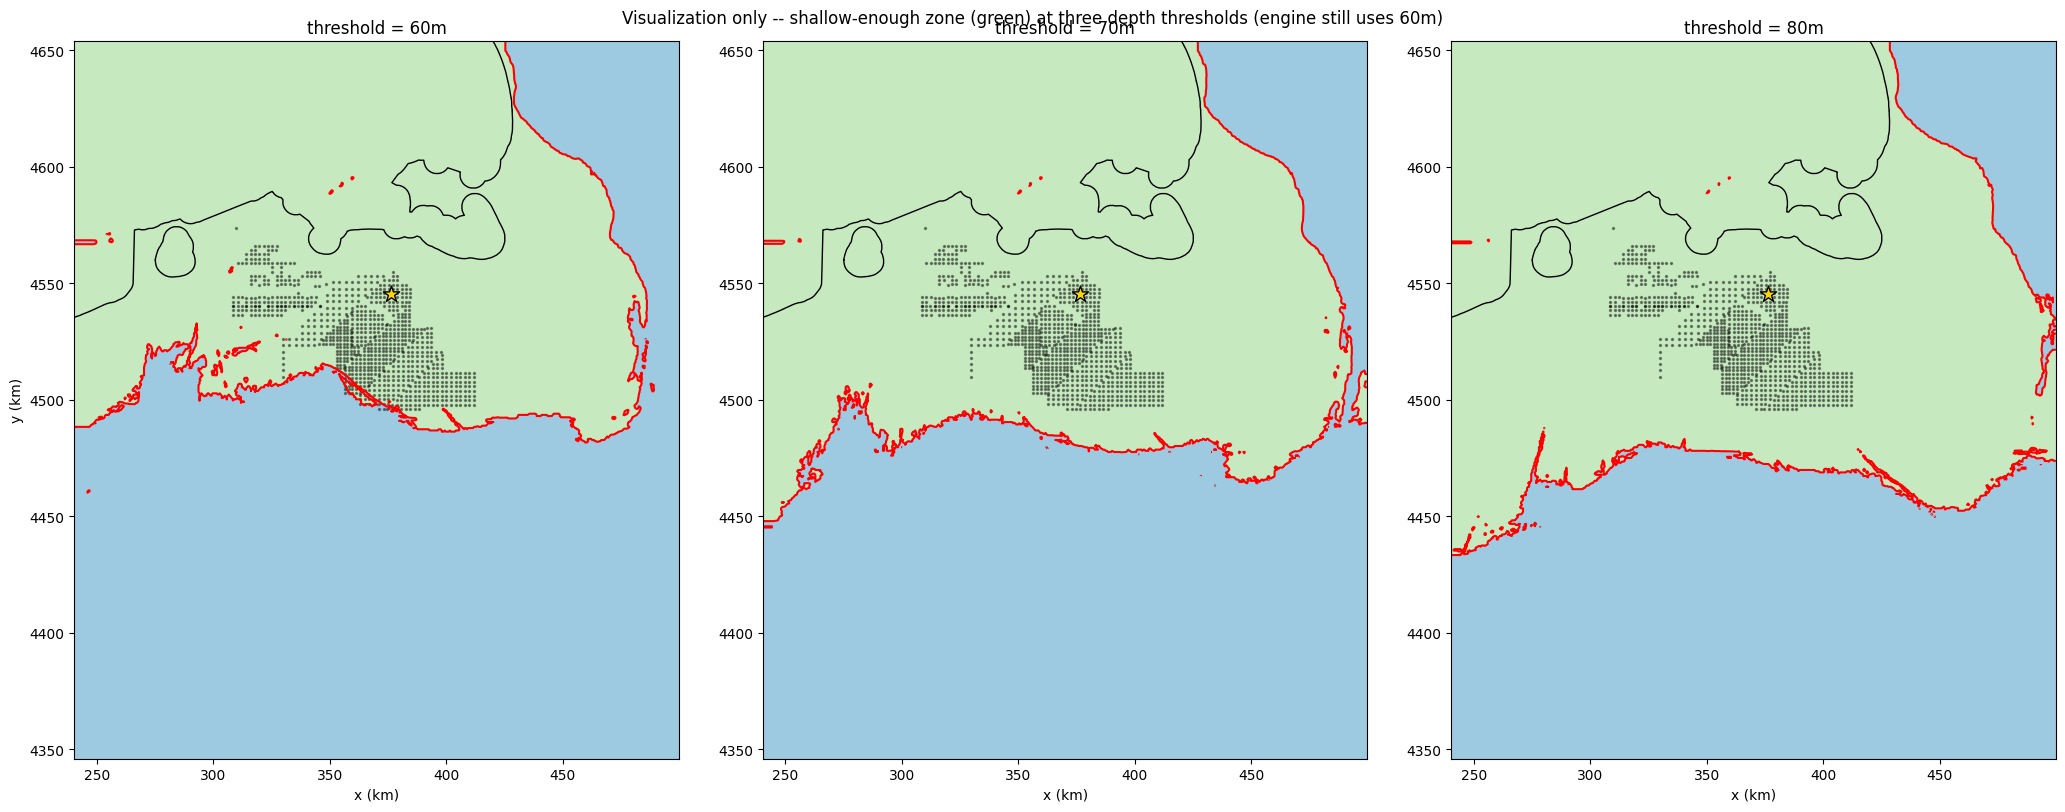

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(21, 8))
for ax, threshold in zip(axes, [60, 70, 80]):
    cs = ax.contourf(GX / 1000, GY / 1000, GZ, levels=[0, threshold, 3200], colors=["#c7e9c0", "#9ecae1"])
    ax.contour(GX / 1000, GY / 1000, GZ, levels=[threshold], colors="red", linewidths=1.5)
    for line in sla_lines_utm:
        ax.plot(line[:, 0] / 1000, line[:, 1] / 1000, color="black", linewidth=1.0)
    ax.scatter(cluster_all_x / 1000, cluster_all_y / 1000, s=2, color="black", alpha=0.4)
    ax.scatter(*vineyard_center_now / 1000, marker="*", s=150, color="gold", edgecolor="black", zorder=5)
    ax.set_xlim(gx.min() / 1000, gx.max() / 1000)
    ax.set_ylim(gy.min() / 1000, gy.max() / 1000)
    ax.set_aspect("equal")
    ax.set_xlabel("x (km)")
    ax.set_title(f"threshold = {threshold}m")
axes[0].set_ylabel("y (km)")
fig.suptitle("Visualization only -- shallow-enough zone (green) at three depth thresholds (engine still uses 60m)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "bathymetry_threshold_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## 3. Connection plausibility

Wake physics does not care about export cables, but plausibility does: a farm proposed far from any real point of interconnection is not a scenario a real developer would pursue. Uses the 5 real substation coordinates already in `wind_farm_us.yaml` (Vineyard, Revolution x2, South Fork, Sunrise) as a rough proxy, not a full electrical design.

In [9]:
SUBSTATIONS = []
for farm in wind_farm_us:
    for sub in farm.get("electrical_substations", []):
        c = sub["electrical_substation"]["coordinates"]
        SUBSTATIONS.append((c["x"][0], c["y"][0]))
SUBSTATIONS = np.array(SUBSTATIONS)
substation_tree = cKDTree(SUBSTATIONS)
MAX_CONNECTION_DISTANCE_M = 100_000  # was 70km, inconsistent with DISTANCE_BANDS_KM's 90km ceiling --
# measured directly (Section 8.1): at 70km, the 75-90km band was only 40.8% geometrically reachable
# (some angle sectors 0%), starving that band regardless of seed. 100km gives real margin above the
# band's own 90km max radius (substations are offset from VINEYARD_CENTER, not colocated with it).

def distance_to_nearest_substation(xs, ys):
    d, _ = substation_tree.query(np.column_stack([xs, ys]))
    return d

def is_connection_plausible(xs, ys):
    return distance_to_nearest_substation(xs, ys) < MAX_CONNECTION_DISTANCE_M

print(f"{len(SUBSTATIONS)} real substations loaded")

5 real substations loaded


## 4. Distance x alignment placement grid

Candidate positions for a new farm are drawn from a stratified grid -- distance band from Vineyard Wind x angular sector -- instead of free uniform placement, so the rare-but-important cell (close and aligned with the prevailing wind) is not left to chance.

In [10]:
vineyard = next(f for f in wind_farm_us if f["name"] == "Vineyard Wind")
VINEYARD_CENTER = np.array([
    np.mean(vineyard["layouts"][0]["coordinates"]["x"]),
    np.mean(vineyard["layouts"][0]["coordinates"]["y"]),
])

DISTANCE_BANDS_KM = [(3, 10), (10, 20), (20, 30), (30, 45), (45, 60), (60, 75), (75, 90)]
ANGLE_SECTORS_DEG = np.arange(0, 360, 30)  # same 12-sector convention as the wind rose

def placement_from_cell(distance_band, angle_deg, rng):
    r = rng.uniform(distance_band[0], distance_band[1]) * 1000
    theta = np.radians(angle_deg + rng.uniform(-15, 15))  # jitter within the sector
    dx, dy = r * np.sin(theta), r * np.cos(theta)  # compass bearing -> x,y
    return VINEYARD_CENTER[0] + dx, VINEYARD_CENTER[1] + dy

## 5. Farm generator -- boundary walked, placed, filled

Given a target capacity, a turbine, a spacing, and a candidate cell, this sizes the required footprint area (`Density_Power_Study`'s footprint logic), generates a boundary with `staircase.grow_staircase_boundary` (a direct rectilinear corner-walk calibrated against the 10 real leases on solidity, aspect ratio, staircase run-length, and corridor clearance -- see `staircase.py`'s module docstring for the full methodology and the two earlier methods it superseded), moves it to the candidate position, and grid-fills it with turbines. No rotation is sampled per farm anymore -- the walk already runs on the same 0/90 regional grid the real leases sit on (measured, not assumed), so there is nothing left to rotate.

A candidate is rejected and re-tried if any part of its boundary crosses into state waters (not just its center), if any turbine falls in water deeper than 80 m, or if it is implausibly far from a connection point.

Separation from other farms is checked edge-to-edge (`shape.distance`), the same convention as the benchmark paper (Rodrigues & Moura 2025) -- but the minimum gap is set to 0 m (overlap forbidden, touching allowed), not an arbitrary buffer: checking the 13 real leases pairwise, the closest pairs (New England Wind 1/Beacon Wind, Revolution Wind/South Fork Wind, and others) sit exactly 0 m apart, edge-to-edge, in reality. An enforced minimum gap of, say, 2 km would have rejected placements this real cluster itself already contains -- realistic here means only "not overlapping", not "kept apart".

In [11]:
def grid_fill_points(polygon, diameter, spacing_d):
    spacing = spacing_d * diameter
    xmin, ymin, xmax, ymax = polygon.bounds
    xs = np.arange(xmin, xmax + spacing, spacing)
    ys = np.arange(ymin, ymax + spacing, spacing)
    return np.array([(x, y) for x in xs for y in ys if polygon.contains(Point(x, y))])

MIN_FARM_SEPARATION_M = 800.0  # real leases can sit at 0m from each other (negotiated), but a speculative new farm landing exactly on an existing boundary by chance is not a realistic default -- small buffer instead

def is_far_enough(shape, existing_shapes, min_sep=MIN_FARM_SEPARATION_M):
    for other in existing_shapes:
        if shape.intersection(other).area > 0:  # actual overlap, always rejected regardless of min_sep
            return False
        if shape.distance(other) < min_sep:
            return False
    return True

def sample_exterior(shape, spacing=300.0):
    """Vertices alone can miss a state-water notch cut into a long straight edge --
    sample the whole boundary at a fixed spacing instead of just the corners."""
    exterior = shape.exterior
    n = max(int(exterior.length // spacing), 12)
    dists = np.linspace(0, exterior.length, n)
    pts = [exterior.interpolate(d) for d in dists]
    return np.array([p.x for p in pts]), np.array([p.y for p in pts])

def generate_farm(target_capacity_mw, turbine_spec, spacing_d, distance_band, angle_deg, rng, existing_shapes, max_tries=150):
    n_needed = int(np.ceil(target_capacity_mw / turbine_spec["rated_mw"]))
    target_area_km2 = n_needed * (spacing_d * turbine_spec["diameter"]) ** 2 / 1e6

    for _ in range(max_tries):
        target_xy = placement_from_cell(distance_band, angle_deg, rng)
        raw_shape, n_corners, achieved_km2 = grow_staircase_boundary(target_area_km2, rng, theta1_deg=0.0)
        if raw_shape is None:
            continue  # walk failed to close within its own retry budget -- try a fresh draw
        shape = affinity.translate(raw_shape, xoff=target_xy[0] - raw_shape.centroid.x,
                                    yoff=target_xy[1] - raw_shape.centroid.y)

        pts = grid_fill_points(shape, turbine_spec["diameter"], spacing_d)
        if len(pts) == 0:
            continue
        bx, by = sample_exterior(shape)
        if not is_federal(bx, by).all():
            continue
        if not is_shallow_enough(pts[:, 0], pts[:, 1]).all():
            continue
        if not is_connection_plausible(np.array([target_xy[0]]), np.array([target_xy[1]]))[0]:
            continue
        if not is_far_enough(shape, existing_shapes):
            continue
        return shape, pts, n_corners
    return None, None, None

### 5.1 Demo -- a few example farms

300MW DTU10MW @ (30, 45)km/90deg: 31 turbines, n_corners=6
600MW Haliade-X 13MW @ (30, 45)km/150deg: no valid placement found
300MW Haliade-X 15.5MW @ (45, 60)km/300deg: 17 turbines, n_corners=9


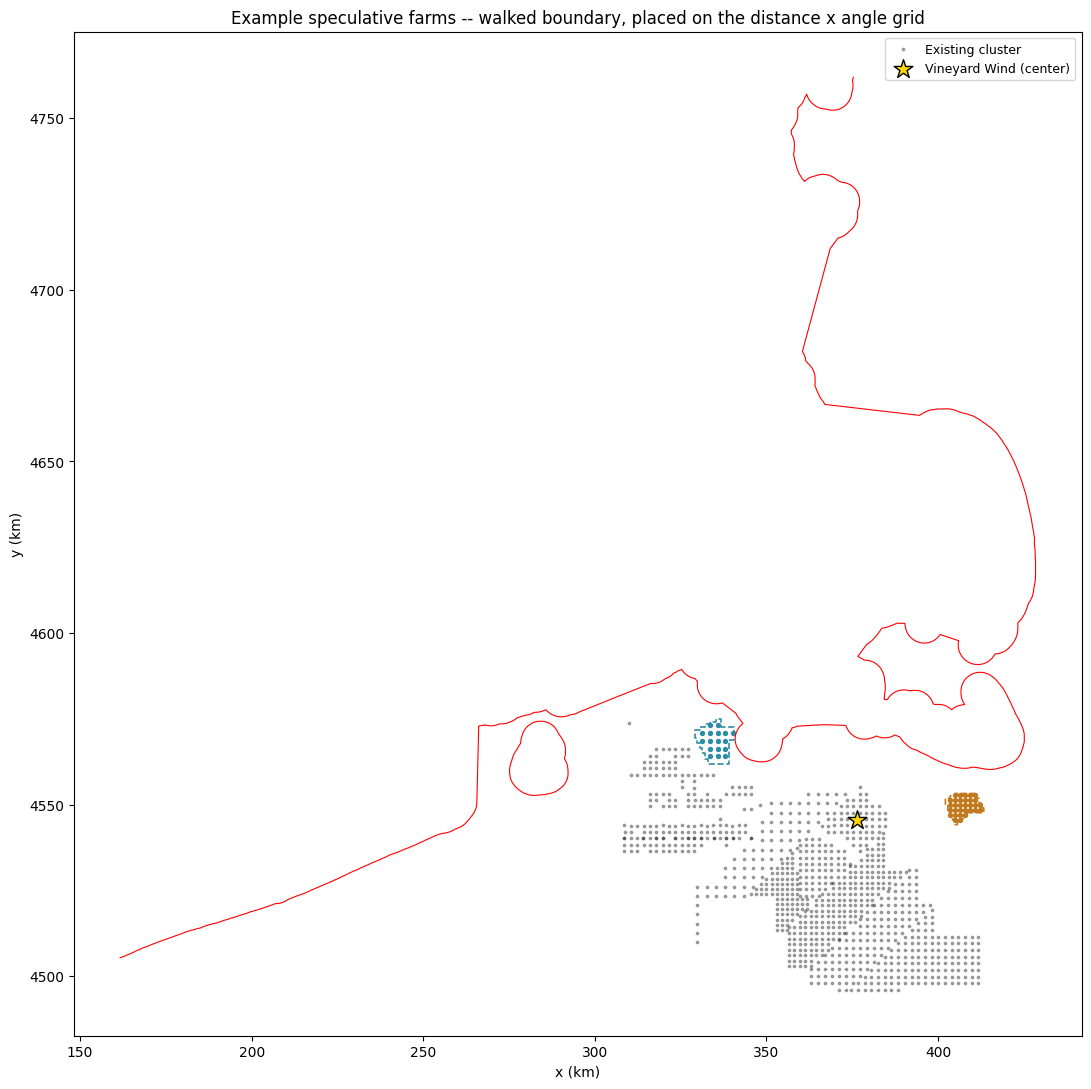

In [12]:
rng = np.random.default_rng(3)
demo_specs = [
    (300, "DTU10MW", 8.0, (30, 45), 90),
    (600, "Haliade-X 13MW", 8.0, (30, 45), 150),
    (300, "Haliade-X 15.5MW", 9.0, (45, 60), 300),
]

existing_shapes = list(LEASE_TEMPLATES.values())

fig, ax = plt.subplots(figsize=(11, 11))
for line in sla_lines_utm:
    ax.plot(line[:, 0] / 1000, line[:, 1] / 1000, color="red", linewidth=0.8)
ax.scatter(cluster_all_x / 1000, cluster_all_y / 1000, s=3, color="black", alpha=0.3, label="Existing cluster")
ax.scatter(*VINEYARD_CENTER / 1000, marker="*", s=200, color="gold", edgecolor="black", label="Vineyard Wind (center)", zorder=5)

for (cap, name, sd, band, angle) in demo_specs:
    shape, pts, n_corners = generate_farm(cap, TURBINES[name], sd, band, angle, rng, existing_shapes)
    if shape is None:
        print(f"{cap}MW {name} @ {band}km/{angle}deg: no valid placement found")
        continue
    existing_shapes.append(shape)
    bx, by = shape.exterior.xy
    ax.plot(np.array(bx) / 1000, np.array(by) / 1000, "--", color=COLORS[name], linewidth=1.2)
    ax.scatter(pts[:, 0] / 1000, pts[:, 1] / 1000, s=8, color=COLORS[name])
    print(f"{cap}MW {name} @ {band}km/{angle}deg: {len(pts)} turbines, n_corners={n_corners}")

ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_aspect("equal")
ax.legend(fontsize=9)
ax.set_title("Example speculative farms -- walked boundary, placed on the distance x angle grid")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "demo_generated_farms.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Fragmentation -- budget to farm list

Regional capacity targets from BOEM declared counts (low) and the NREL conservative:mid:advanced ratio (Fuchs et al. 2024, Table 8, ~1:2.5:4) applied to that regional base -- not the national 80 GW figure, which is only context. Given a level, the delta above what already exists is split into individual farms by drawing sizes from the empirical distribution of the 9 known real projects until the delta is filled -- the number of farms falls out of the draw, it is not chosen.

In [13]:
REGIONAL_CAPACITY_MW = {"low": 7872.0, "medium": 7872.0 * 2.5, "high": 7872.0 * 4.0}
REAL_FARM_SIZES_MW = [30, 132, 572, 715, 780, 806, 924, 1833, 2080]  # the 9 known real projects, Section 6 of Density_Power_Study

def fragment_budget(delta_mw, rng):
    farms, remaining = [], delta_mw
    while remaining > REAL_FARM_SIZES_MW[0] / 2:
        draw = rng.choice(REAL_FARM_SIZES_MW)
        farms.append(min(draw, remaining))
        remaining -= draw
    return farms

for level in ["low", "medium", "high"]:
    delta = REGIONAL_CAPACITY_MW[level] - REGIONAL_CAPACITY_MW["low"]
    farms = fragment_budget(delta, np.random.default_rng(1))
    print(f"{level}: total={REGIONAL_CAPACITY_MW[level]/1000:.1f}GW, delta={delta/1000:.1f}GW -> {len(farms)} new farms: {[round(f) for f in farms]} MW")

low: total=7.9GW, delta=0.0GW -> 0 new farms: [] MW
medium: total=19.7GW, delta=11.8GW -> 12 new farms: [780, 780, 924, 2080, 30, 132, 1833, 2080, 572, 572, 1833, 192] MW
high: total=31.5GW, delta=23.6GW -> 25 new farms: [780, 780, 924, 2080, 30, 132, 1833, 2080, 572, 572, 1833, 715, 572, 1833, 572, 715, 806, 780, 30, 30, 1833, 924, 1833, 780, 577] MW


## 7. Full scenario -- populate the region, many times

`populate_scenario(level, rng)` is the whole engine in one call: pick a PD level, fragment its delta into farms, place each one on the distance x angle grid, avoiding every farm placed before it in the same draw plus the entire existing cluster. This is also exactly the interface the Monte Carlo loop will call -- what changes between "a demo" and "the real thing" is only how many times it gets called and what gets logged from each call, not the function itself. S

## 8. Diagnostics -- density, and why placements cluster near the existing area

Two checks asked for directly: (a) how dense the generated farms actually come out (turbines/km2, MW/km2, compared to the `Density_Power_Study` reference range), and (b) whether new farms failing to reach the far distance bands is a seed-luck issue or a structural one. For (b): `MAX_CONNECTION_DISTANCE_M` is 70 km, but `DISTANCE_BANDS_KM` samples out to 90 km, and all 5 real substations sit near the existing cluster itself (Vineyard, Revolution x2, South Fork, Sunrise) -- so a candidate drawn far from `VINEYARD_CENTER` can be geometrically unreachable by the connection-distance filter alone, before bathymetry or SLA are even checked. The cell below measures this directly, band by band, angle by angle -- not simulated, the real `is_connection_plausible`/`is_shallow_enough`/`is_federal` functions already defined above.

draw 0: 7 new farms placed, cluster fill = 967 turbines, bands used: [(20, 30), (30, 45), (45, 60), (60, 75)]
draw 1: 9 new farms placed, cluster fill = 838 turbines, bands used: [(20, 30), (45, 60), (60, 75), (75, 90)]
draw 2: 4 new farms placed, cluster fill = 958 turbines, bands used: [(20, 30), (45, 60), (60, 75)]
draw 3: 7 new farms placed, cluster fill = 881 turbines, bands used: [(20, 30), (45, 60), (60, 75), (75, 90)]
draw 4: 9 new farms placed, cluster fill = 834 turbines, bands used: [(20, 30), (30, 45), (60, 75), (75, 90)]
draw 5: 5 new farms placed, cluster fill = 960 turbines, bands used: [(20, 30), (30, 45), (60, 75), (75, 90)]
draw 6: 11 new farms placed, cluster fill = 757 turbines, bands used: [(20, 30), (30, 45), (45, 60), (60, 75), (75, 90)]
draw 7: 9 new farms placed, cluster fill = 831 turbines, bands used: [(10, 20), (30, 45), (45, 60), (60, 75)]
draw 8: 11 new farms placed, cluster fill = 875 turbines, bands used: [(10, 20), (20, 30), (45, 60), (60, 75), (75, 90)

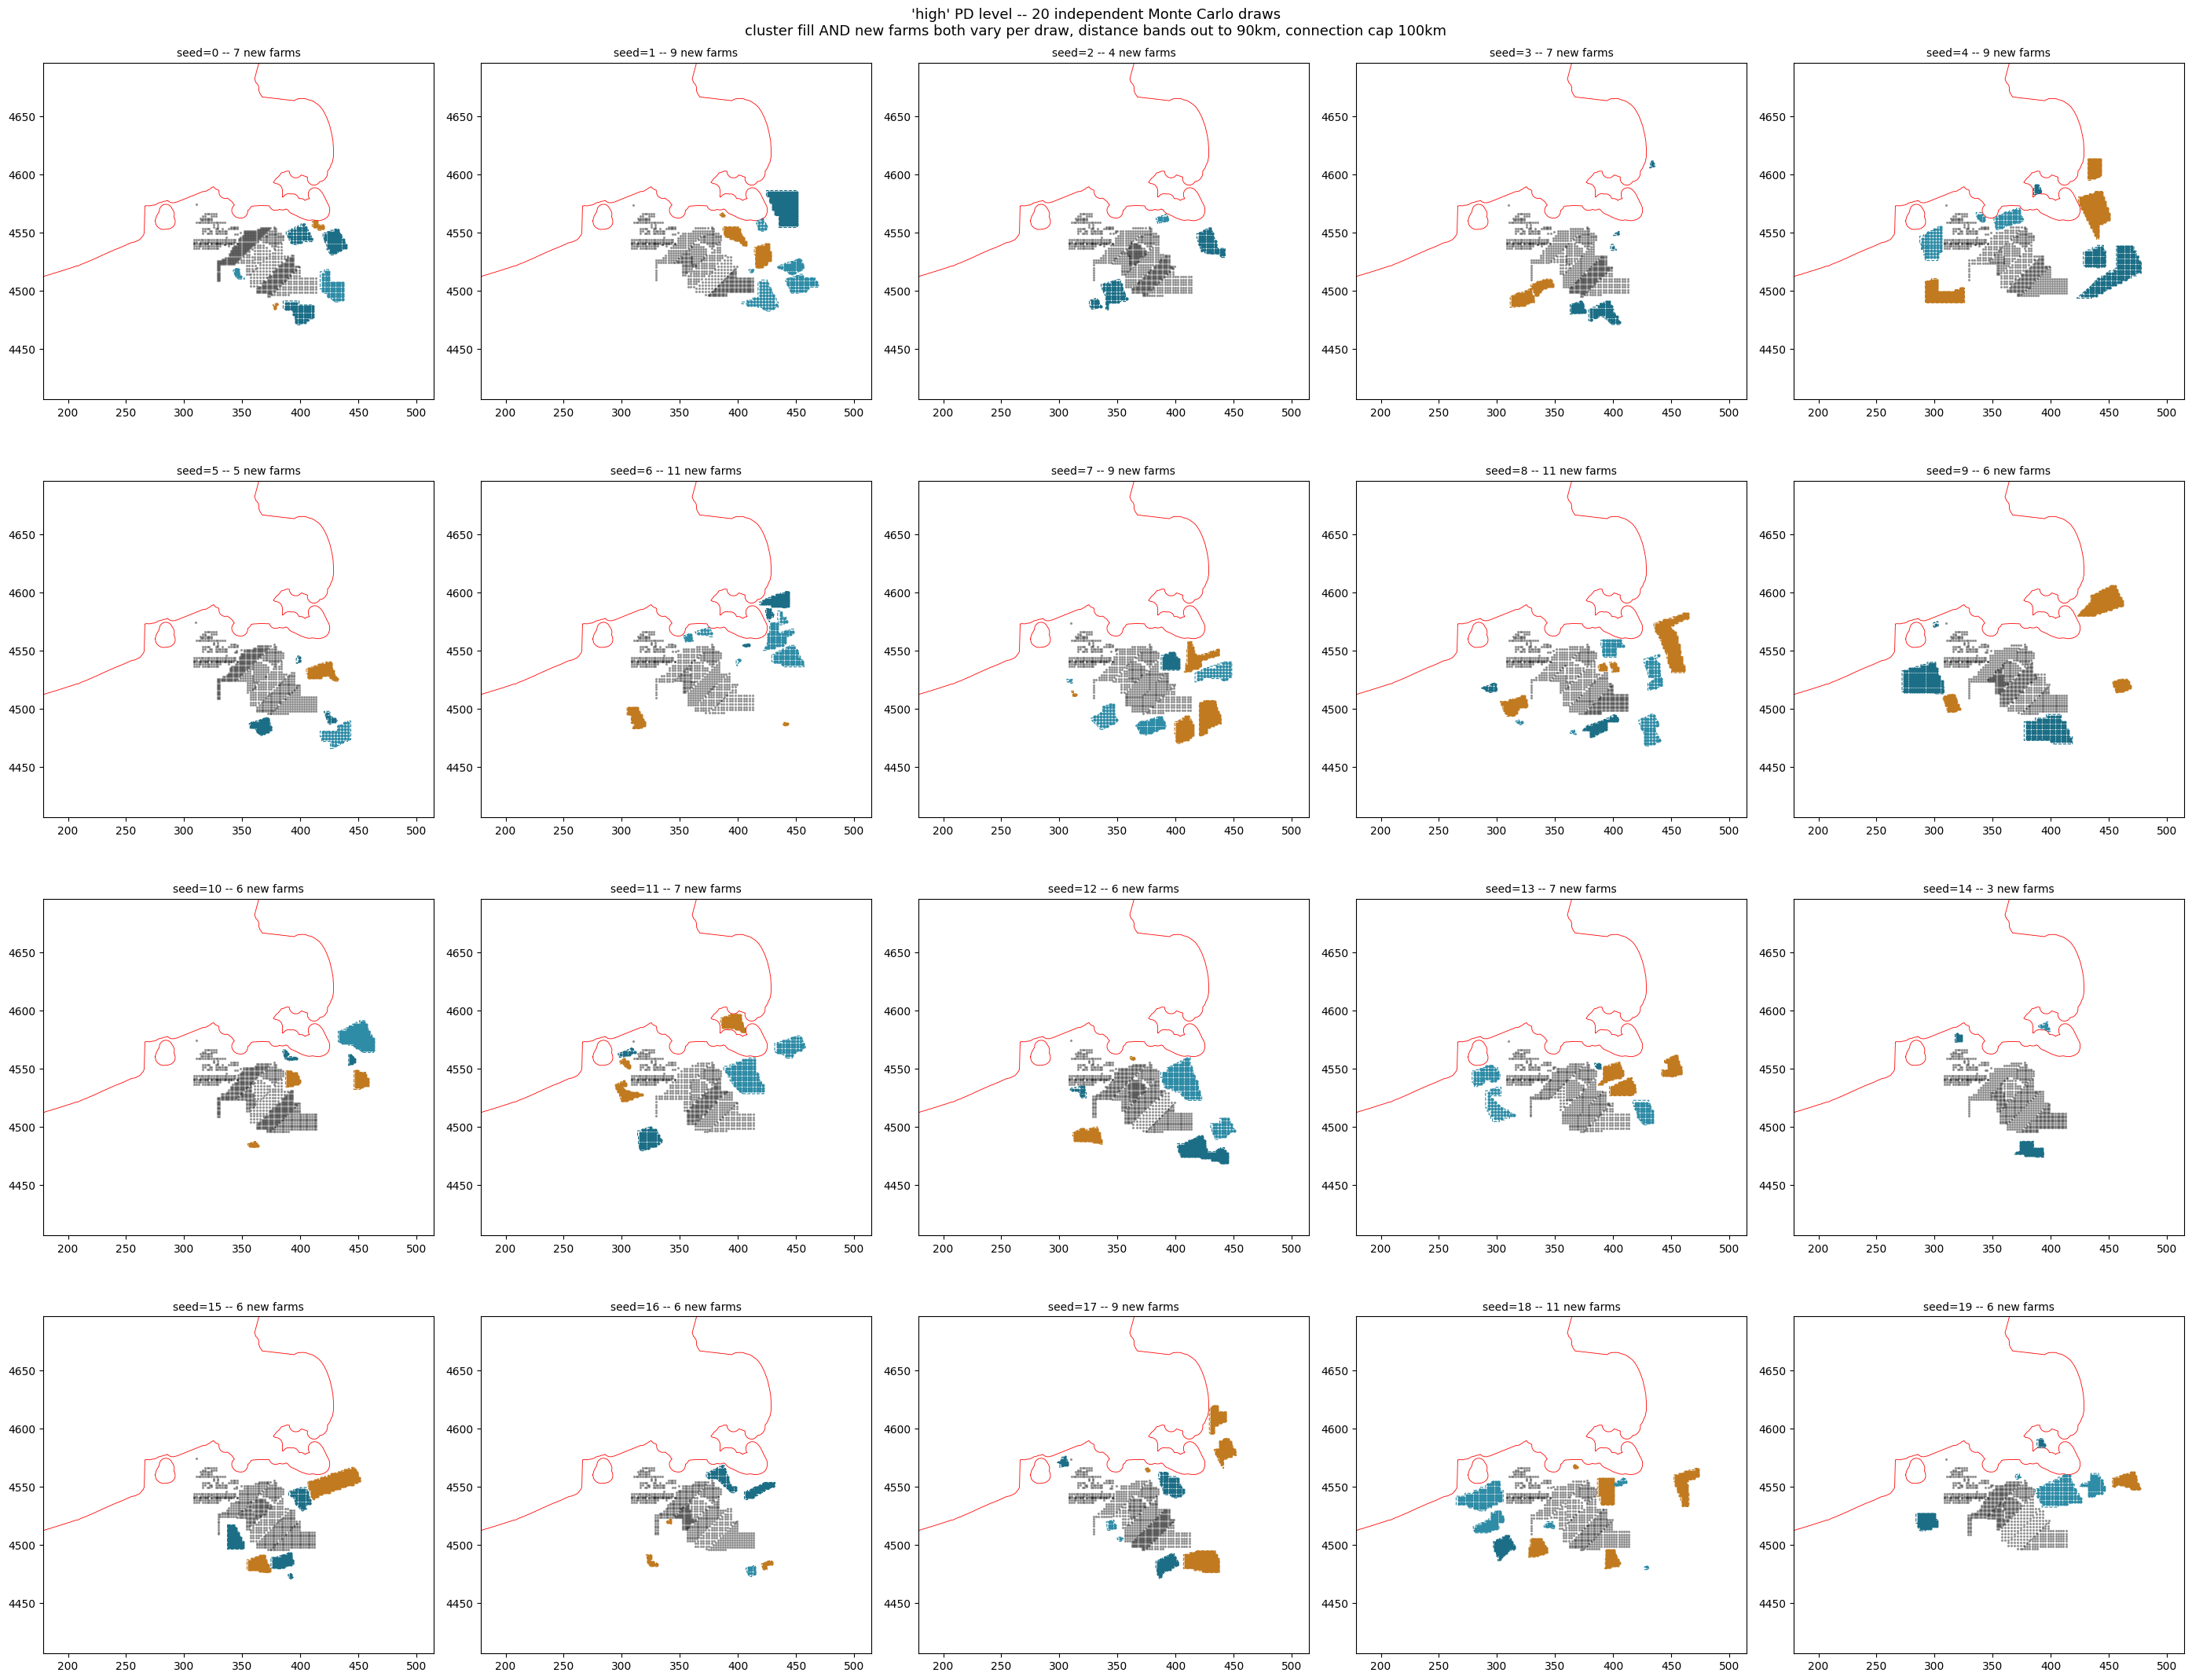

In [15]:
def populate_scenario(level, rng):
    cluster_x, cluster_y = fill_rest_of_cluster(rng)
    delta = REGIONAL_CAPACITY_MW[level] - REGIONAL_CAPACITY_MW["low"]
    farm_budgets = fragment_budget(delta, rng)
    existing_shapes = list(LEASE_TEMPLATES.values())
    results = []
    for cap in farm_budgets:
        name = rng.choice(list(TURBINES.keys()))
        spacing_d = rng.uniform(8.0, 11.0)
        band = DISTANCE_BANDS_KM[rng.integers(len(DISTANCE_BANDS_KM))]
        angle = ANGLE_SECTORS_DEG[rng.integers(len(ANGLE_SECTORS_DEG))]
        shape, pts, n_corners = generate_farm(cap, TURBINES[name], spacing_d, band, angle, rng, existing_shapes, max_tries=200)
        if shape is not None:
            existing_shapes.append(shape)
            results.append(dict(capacity_mw=cap, turbine=name, shape=shape, pts=pts, band=band))
    return cluster_x, cluster_y, results

N_DRAWS = 20
target_level = "high"
draws = [populate_scenario(target_level, np.random.default_rng(seed)) for seed in range(N_DRAWS)]
for i, (cx, cy, scenario) in enumerate(draws):
    bands_used = sorted({f["band"] for f in scenario})
    print(f"draw {i}: {len(scenario)} new farms placed, cluster fill = {len(cx)} turbines, bands used: {bands_used}")

REAL_X_ALL = np.concatenate(REAL_FARM_X)
REAL_Y_ALL = np.concatenate(REAL_FARM_Y)
XLIM = ((REAL_X_ALL.min() - 130_000) / 1000, (REAL_X_ALL.max() + 130_000) / 1000)
YLIM = ((REAL_Y_ALL.min() - 130_000) / 1000, (REAL_Y_ALL.max() + 130_000) / 1000)

fig, axes = plt.subplots(4, 5, figsize=(28, 22))
for ax, (cx, cy, scenario), seed in zip(axes.flat, draws, range(N_DRAWS)):
    for line in sla_lines_utm:
        ax.plot(line[:, 0] / 1000, line[:, 1] / 1000, color="red", linewidth=0.6)
    ax.scatter(cx / 1000, cy / 1000, s=2, color="black", alpha=0.3)
    for f in scenario:
        c = COLORS.get(f["turbine"], "gray")
        bx, by = f["shape"].exterior.xy
        ax.plot(np.array(bx) / 1000, np.array(by) / 1000, "--", color=c, linewidth=0.8)
        ax.scatter(f["pts"][:, 0] / 1000, f["pts"][:, 1] / 1000, s=4, color=c)
    ax.set_xlim(*XLIM)
    ax.set_ylim(*YLIM)
    ax.set_aspect("equal")
    ax.set_title(f"seed={seed} -- {len(scenario)} new farms", fontsize=10)

fig.suptitle(f"'{target_level}' PD level -- {N_DRAWS} independent Monte Carlo draws\n"
             f"cluster fill AND new farms both vary per draw, distance bands out to 90km, connection cap 100km", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "monte_carlo_scenario_gallery.png", dpi=150)

In [ ]:
### 8.1 Feasibility by distance band x angle -- pure geometry first, then full filter

N_PROBE = 40  # random points per band/angle cell

print("Connection-distance ceiling alone (ignores bathymetry/SLA) -- fraction of random points "
      "in each band x angle cell that are within 70km of ANY real substation:")
rng_probe = np.random.default_rng(0)
band_conn_frac = {}
for band in DISTANCE_BANDS_KM:
    fracs = []
    for angle in ANGLE_SECTORS_DEG:
        pts = np.array([placement_from_cell(band, angle, rng_probe) for _ in range(N_PROBE)])
        ok = is_connection_plausible(pts[:, 0], pts[:, 1])
        fracs.append(ok.mean())
    band_conn_frac[band] = np.mean(fracs)
    print(f"  {band[0]:3d}-{band[1]:3d} km: {np.mean(fracs) * 100:5.1f}% of points reachable "
          f"(min over angle sectors: {min(fracs) * 100:.0f}%, max: {max(fracs) * 100:.0f}%)")

print("\nFull generate_farm() success rate by band (300 MW Haliade-X 13MW @ 8D, all filters, max_tries=150):")
for band in DISTANCE_BANDS_KM:
    n_ok = 0
    for seed in range(20):
        rng_i = np.random.default_rng(10_000 + seed)
        angle = ANGLE_SECTORS_DEG[rng_i.integers(len(ANGLE_SECTORS_DEG))]
        shape, pts, n_corners = generate_farm(300, TURBINES["Haliade-X 13MW"], 8.0, band, angle,
                                               rng_i, list(LEASE_TEMPLATES.values()), max_tries=150)
        if shape is not None:
            n_ok += 1
    print(f"  {band[0]:3d}-{band[1]:3d} km: {n_ok:2d}/20 succeeded")

### 8.2 Turbine density of generated farms vs. the `Density_Power_Study` reference

Nominal density (MW/km2, geometry only -- capacity / achieved footprint area), for a sweep of capacities and spacings actually used by `generate_farm`/`populate_scenario` (8-11D, all 3 turbine models). `Density_Power_Study` established the reference range at 7D-11D for these same turbines; the two should overlap if this generator's packing is consistent with that study, not denser.

In [ ]:
density_rows = []
rng_d = np.random.default_rng(7)
for cap in [132, 300, 572, 924, 1833]:
    for turbine_name, spec in TURBINES.items():
        for spacing_d in [8.0, 9.5, 11.0]:
            n_needed = int(np.ceil(cap / spec["rated_mw"]))
            target_km2 = n_needed * (spacing_d * spec["diameter"]) ** 2 / 1e6
            shape, n_corners, achieved_km2 = grow_staircase_boundary(target_km2, rng_d, theta1_deg=0.0)
            if shape is None:
                continue
            pts = grid_fill_points(shape, spec["diameter"], spacing_d)
            n_turbines = len(pts)
            actual_mw = n_turbines * spec["rated_mw"]
            nominal_density = actual_mw / achieved_km2
            density_rows.append(dict(cap=cap, turbine=turbine_name, spacing_d=spacing_d,
                                      n_turbines=n_turbines, actual_mw=actual_mw,
                                      area_km2=achieved_km2, density_mw_km2=nominal_density,
                                      turbines_per_km2=n_turbines / achieved_km2))

import pandas as pd
density_df = pd.DataFrame(density_rows)
print(density_df.groupby("spacing_d")[["density_mw_km2", "turbines_per_km2"]].mean())
print(f"\noverall: density mean={density_df['density_mw_km2'].mean():.2f} MW/km2, "
      f"range {density_df['density_mw_km2'].min():.2f}-{density_df['density_mw_km2'].max():.2f} MW/km2")
print(f"turbines/km2: mean={density_df['turbines_per_km2'].mean():.3f}, "
      f"range {density_df['turbines_per_km2'].min():.3f}-{density_df['turbines_per_km2'].max():.3f}")
print("\nDensity_Power_Study reference (7D-11D, same 3 turbines): roughly 2.2-5.5 MW/km2 nominal "
      "(7D upper bound ~5.5, 11D lower bound ~2.2, scaling ~1/spacing_d^2)")

## 9. Explore -- push the knobs, one cell per configuration

`explore_scenario()` wraps the same `populate_scenario`/`generate_farm` logic above, but exposes the three knobs as arguments instead of needing to edit the global cells every time: `spacing_range` (density), `distance_bands` (how far out to sample, and in what bands), `connection_cap_km` (**must stay `>=` the top of `distance_bands` -- Section 8 is the reason why**), and `capacity_mw` (a fixed budget instead of a PD level, for "just give me N farms" control). It temporarily overrides the matching globals, runs `n_draws` independent scenarios, plots them in a grid, then restores the globals -- so cells above (or another call right after) are unaffected. Copy the example cell below, change the numbers, run -- one cell per exploration, no need to touch Sections 3-7.

In [ ]:
def explore_scenario(level="high", n_draws=12, seed_offset=0, spacing_range=(8.0, 11.0),
                      distance_bands=None, connection_cap_km=None, capacity_mw=None, title_extra=""):
    """One-off exploration wrapper -- widen spacing, distance bands, the
    connection cap, or fix a capacity budget directly, for a single gallery,
    without touching the global config the main pipeline (Sections 3-7) uses.
    Globals are restored on exit, including on error.

    Runtime scales with how many farms end up in the budget (each one tries
    up to `max_tries` placements, each checked against every farm already
    placed) -- `capacity_mw` much above the 'high' level's ~24 GW delta, or
    `n_draws` much above ~12-15, can turn a few-second cell into a very long
    one. Scale up gradually and watch the per-draw farm counts printed below
    rather than jumping straight to an extreme value.
    """
    global DISTANCE_BANDS_KM, MAX_CONNECTION_DISTANCE_M
    orig_bands, orig_cap = DISTANCE_BANDS_KM, MAX_CONNECTION_DISTANCE_M
    try:
        if distance_bands is not None:
            DISTANCE_BANDS_KM = distance_bands
        if connection_cap_km is not None:
            MAX_CONNECTION_DISTANCE_M = connection_cap_km * 1000
        if connection_cap_km is None and distance_bands is not None:
            implied_cap_km = distance_bands[-1][1]
            if implied_cap_km * 1000 > MAX_CONNECTION_DISTANCE_M:
                print(f"WARNING: distance_bands reaches {implied_cap_km}km but MAX_CONNECTION_DISTANCE_M "
                      f"is only {MAX_CONNECTION_DISTANCE_M/1000:.0f}km -- the far bands will mostly fail "
                      f"(this is exactly the Section 8 bug). Pass connection_cap_km >= {implied_cap_km}.")

        def _populate(rng):
            cluster_x, cluster_y = fill_rest_of_cluster(rng)
            farm_budgets = fragment_budget(capacity_mw, rng) if capacity_mw is not None else \
                fragment_budget(REGIONAL_CAPACITY_MW[level] - REGIONAL_CAPACITY_MW["low"], rng)
            existing_shapes = list(LEASE_TEMPLATES.values())
            results = []
            for cap in farm_budgets:
                name = rng.choice(list(TURBINES.keys()))
                spacing_d = rng.uniform(*spacing_range)
                band = DISTANCE_BANDS_KM[rng.integers(len(DISTANCE_BANDS_KM))]
                angle = ANGLE_SECTORS_DEG[rng.integers(len(ANGLE_SECTORS_DEG))]
                shape, pts, n_corners = generate_farm(cap, TURBINES[name], spacing_d, band, angle,
                                                       rng, existing_shapes, max_tries=200)
                if shape is not None:
                    existing_shapes.append(shape)
                    results.append(dict(capacity_mw=cap, turbine=name, shape=shape, pts=pts, band=band))
            return cluster_x, cluster_y, results

        draws = [_populate(np.random.default_rng(seed_offset + s)) for s in range(n_draws)]
    finally:
        DISTANCE_BANDS_KM, MAX_CONNECTION_DISTANCE_M = orig_bands, orig_cap  # always restore

    for i, (cx, cy, scenario) in enumerate(draws):
        bands_used = sorted({f["band"] for f in scenario})
        print(f"draw {seed_offset + i}: {len(scenario)} new farms, bands used: {bands_used}")

    ncols = min(n_draws, 4)
    nrows = int(np.ceil(n_draws / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6.5 * nrows), squeeze=False)
    for ax, (cx, cy, scenario), seed in zip(axes.flat, draws, range(seed_offset, seed_offset + n_draws)):
        for line in sla_lines_utm:
            ax.plot(line[:, 0] / 1000, line[:, 1] / 1000, color="red", linewidth=0.6)
        ax.scatter(cx / 1000, cy / 1000, s=2, color="black", alpha=0.3)
        for f in scenario:
            c = COLORS.get(f["turbine"], "gray")
            bx, by = f["shape"].exterior.xy
            ax.plot(np.array(bx) / 1000, np.array(by) / 1000, "--", color=c, linewidth=0.8)
            ax.scatter(f["pts"][:, 0] / 1000, f["pts"][:, 1] / 1000, s=4, color=c)
        ax.set_aspect("equal")
        ax.set_title(f"seed={seed} -- {len(scenario)} new farms", fontsize=9)
    for ax in axes.flat[len(draws):]:
        ax.axis("off")

    band_ceiling = distance_bands[-1][1] if distance_bands else DISTANCE_BANDS_KM[-1][1]
    fig.suptitle(f"{title_extra or level} -- {n_draws} draws, spacing {spacing_range}D, "
                 f"bands out to {band_ceiling}km", fontsize=13)
    fig.tight_layout()
    plt.show()
    return draws


# Example: same 'high' level, but spacing pushed wider (6-13D) and distance out to 130km
_ = explore_scenario(level="high", n_draws=8, seed_offset=200,
                      spacing_range=(6.0, 13.0),
                      distance_bands=[(3, 10), (10, 20), (20, 30), (30, 45), (45, 60),
                                       (60, 75), (75, 90), (90, 110), (110, 130)],
                      connection_cap_km=140,
                      title_extra="Example -- wider spacing + bands to 130km")

In [ ]:
# Example: force a bigger budget directly (capacity_mw) instead of a PD level -- more farms per draw.
# Kept modest (12 GW, close to 'medium') on purpose -- see the runtime note in explore_scenario's
# docstring above before pushing this much higher.
_ = explore_scenario(n_draws=3, seed_offset=400, capacity_mw=16_000.0,
                      title_extra="Example -- fixed 12 GW budget (more farms per draw)")